# scRN_AI — PBMC 3k Pipeline Demo

> **scRN_AI v1.0.0**<br>
> Author: Patrick Grady<br>
> Anthropic Claude Opus 4.6 used for code formatting and cleanup assistance.<br>
> License: MIT License — See LICENSE

**End-to-end demo**: PBMC 3k data → QC → normalization → HVG → PCA → clustering → marker detection → visualization

This notebook walks through the complete scRN_AI pipeline on the classic **10X Genomics PBMC 3k** dataset
(2,700 peripheral blood mononuclear cells). It showcases the package's workflow modules and utility functions
for a real single-cell RNA-seq analysis.

---

### What this notebook demonstrates

| Step | scRN_AI module / function |
|------|-------------------------|
| Load PBMC 3k data | `scanpy.datasets.pbmc3k_processed()` |
| QC filtering | `workflows.preprocess` logic |
| Normalization | `workflows.normalization` (log1p) |
| HVG selection & PCA | `utils.marker_detection.identify_variable_genes()` |
| Clustering | Leiden clustering via scanpy |
| Marker gene detection | `utils.marker_detection.find_cluster_markers()` |
| QC visualization | `utils.plot.qc_violin()`, `qc_scatter()` |
| Expression visualization | `utils.plot.dotplot()`, `stacked_violin()` |
| UMAP visualization | `workflows.visualization` logic |
| Pseudotime (DPT) | `workflows.pseudotime` logic |

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, frameon=False, fontsize=12)

# Import scRN_AI modules
from scrn_ai.utils.marker_detection import (
    identify_variable_genes,
    find_cluster_markers,
    filter_marker_genes,
)
from scrn_ai.utils.plot import (
    qc_violin,
    qc_scatter,
    dotplot,
    stacked_violin,
    pseudotime_heatmap,
    umap_pseudotime,
)

print("Imports OK")

openai package not installed. Install with: pip install openai


Imports OK


## 1. Load the PBMC 3k Dataset

Scanpy ships a pre-processed version of the 10X Genomics PBMC 3k dataset. We'll use the
**raw counts** version to demonstrate the full pipeline from scratch.

If raw counts aren't available, we'll use the processed version and show the workflow
on its raw layer.

In [2]:
# Load the PBMC 3k dataset
# Try raw first; fall back to processed
try:
    adata = sc.datasets.pbmc3k()
    data_source = "raw"
except Exception:
    adata = sc.datasets.pbmc3k_processed()
    data_source = "processed"

print(f"Loaded PBMC 3k ({data_source}): {adata.n_obs} cells × {adata.n_vars} genes")
print(adata)

Loaded PBMC 3k (raw): 2700 cells × 32738 genes
AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


## 2. Quality Control

This mirrors what `scrn_ai preprocess` does under the hood:
calculate QC metrics, filter cells by gene count, and filter by mitochondrial content.

The `workflows.preprocess` module supports `.h5ad`, `.h5`, `.loom`, `.mtx`, and `.csv` inputs.

In [3]:
# Make gene names unique (required for 10X data)
adata.var_names_make_unique()

# Calculate QC metrics — same logic as workflows.preprocess.run()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

n_before = adata.n_obs
print(f"Before QC: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Mitochondrial genes found: {adata.var['mt'].sum()}")

Before QC: 2700 cells × 32738 genes
Mitochondrial genes found: 13


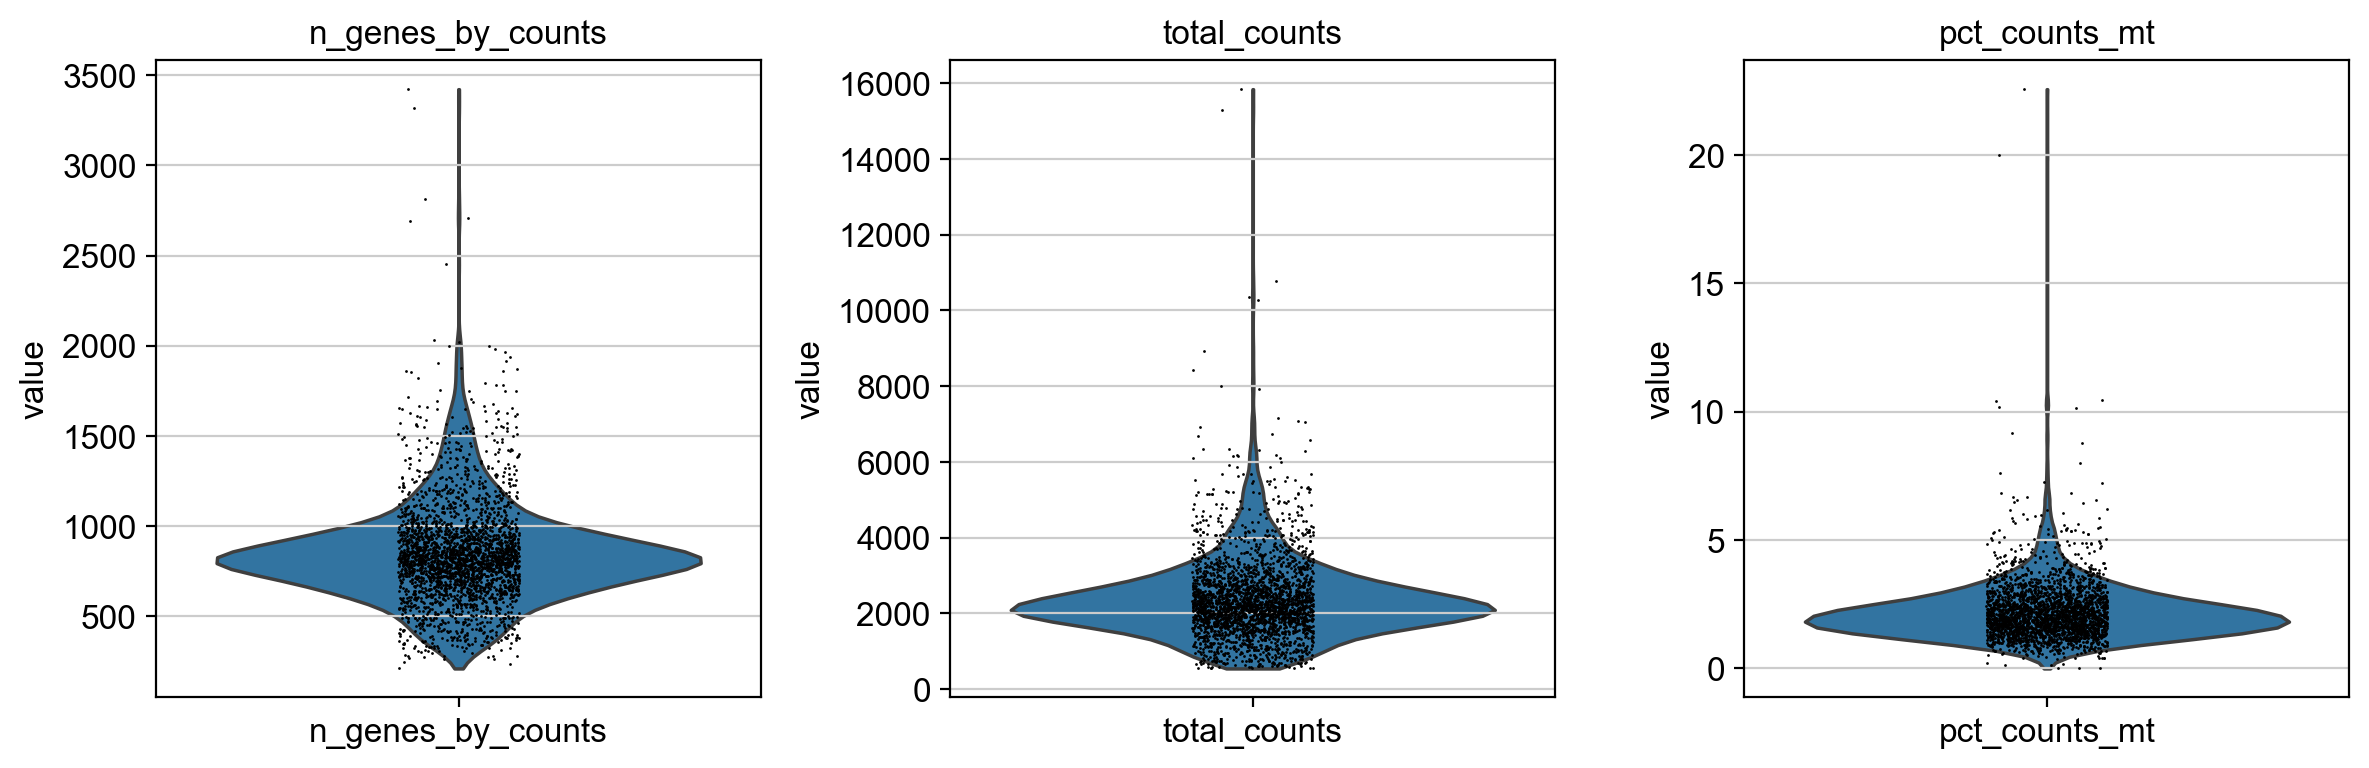

In [4]:
# Visualize QC metrics with scRN_AI plotting utilities
qc_violin(adata, keys=("n_genes_by_counts", "total_counts", "pct_counts_mt"))
plt.show()

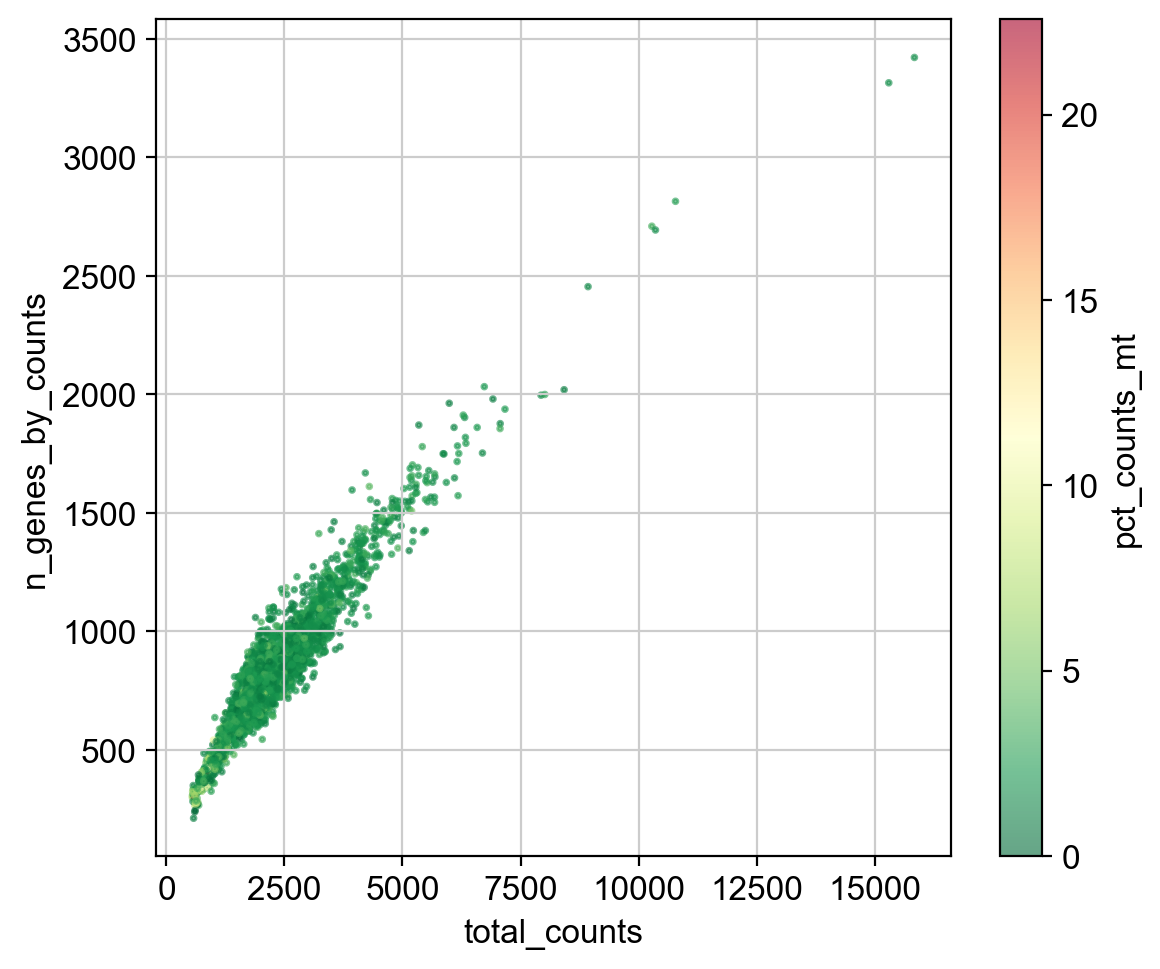

In [5]:
qc_scatter(adata, x="total_counts", y="n_genes_by_counts", color="pct_counts_mt")
plt.show()

In [4]:
# Apply QC filters — same thresholds as the CLI default + mito filter
sc.pp.filter_cells(adata, min_genes=200)
adata = adata[adata.obs.n_genes_by_counts < 2500, :].copy()
adata = adata[adata.obs.pct_counts_mt < 5, :].copy()
sc.pp.filter_genes(adata, min_cells=3)

print(f"After QC: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Removed {n_before - adata.n_obs} cells ({100*(n_before - adata.n_obs)/n_before:.1f}%)")

After QC: 2638 cells × 13656 genes
Removed 62 cells (2.3%)


## 3. Normalization

scRN_AI supports multiple normalization methods via the `normalize` command:
- **Seurat** (LogNormalize, SCTransform) — requires R + Seurat
- **JMP** (TMM, RLE, UpperQuartile) — requires R + edgeR
- **log1p** — pure Python, no R needed
- **scran** — deconvolution size factors (R)
- **sctransform** — variance stabilizing (R)

Here we use `log1p` (scanpy's `normalize_total` + `log1p`), which is the pure-Python
fallback that works everywhere.

In [5]:
# Save raw counts before normalization
adata.layers["counts"] = adata.X.copy()

# log1p normalization — same as workflows.normalization._normalize_log1p()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Store normalized data as raw for later reference
adata.raw = adata

print("Normalization complete (log1p, scale_factor=10000)")

Normalization complete (log1p, scale_factor=10000)


## 4. Feature Selection — Highly Variable Genes

Use scRN_AI's `identify_variable_genes()` to find informative genes for downstream analysis.

Identified 2000 highly variable genes
Top 20 HVGs: ['TNFRSF4', 'CPSF3L', 'ATAD3C', 'C1orf86', 'RER1', 'TNFRSF25', 'TNFRSF9', 'CA6', 'CTNNBIP1', 'SRM', 'UBIAD1', 'DRAXIN', 'NPPA-AS1', 'TNFRSF1B', 'PRDM2', 'EFHD2', 'DDI2', 'SPEN', 'SDHB', 'CAPZB']


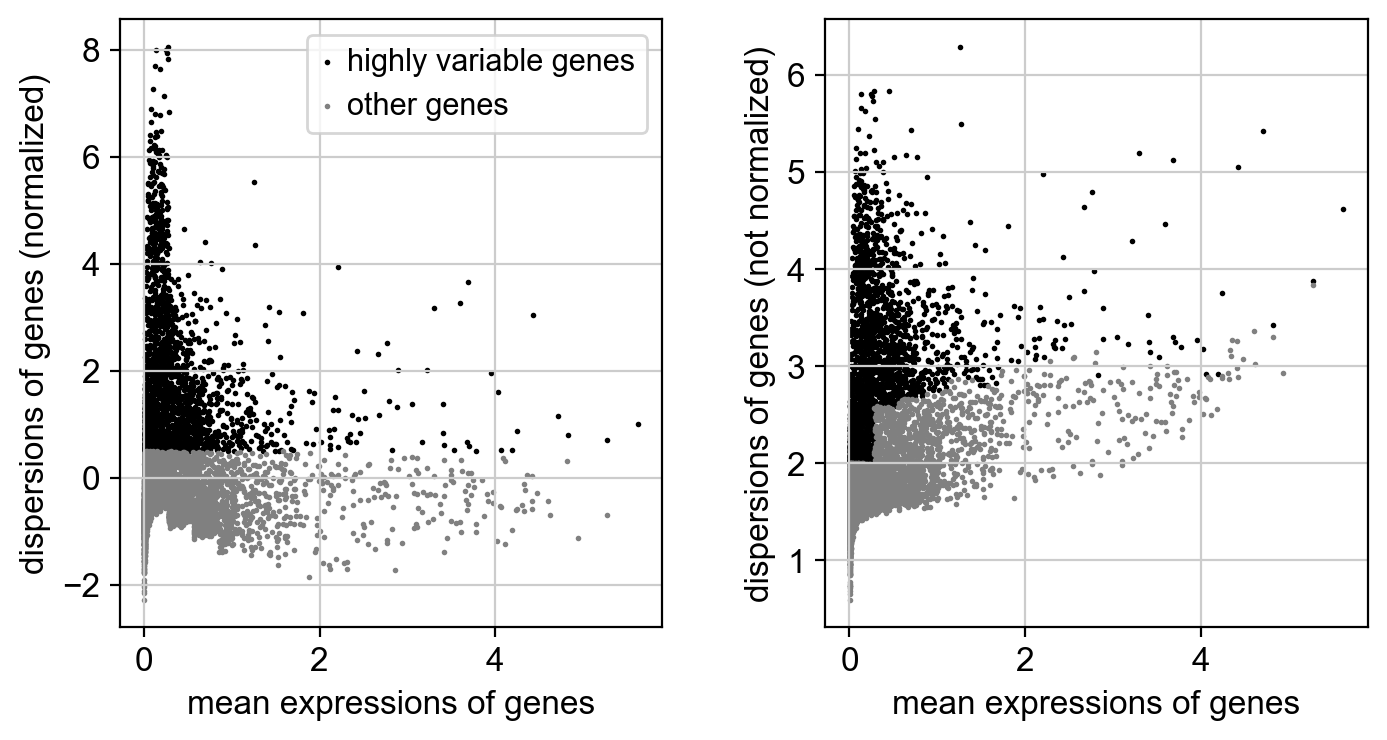

In [6]:
# Identify HVGs using scRN_AI's marker_detection module
hvgs = identify_variable_genes(adata, n_top_genes=2000, flavor="seurat", subset=False)

print(f"Identified {len(hvgs)} highly variable genes")
print(f"Top 20 HVGs: {hvgs[:20]}")

# Visualize
sc.pl.highly_variable_genes(adata)

In [7]:
# Subset to HVGs for dimensionality reduction
adata = adata[:, adata.var.highly_variable].copy()

# Scale gene expression
sc.pp.scale(adata, max_value=10)

print(f"Working with {adata.n_vars} HVGs")

Working with 2000 HVGs


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


## 5. Dimensionality Reduction & Clustering

PCA → neighbor graph → UMAP → Leiden clustering.
This is the same pipeline that `scrn_ai umap` runs internally.

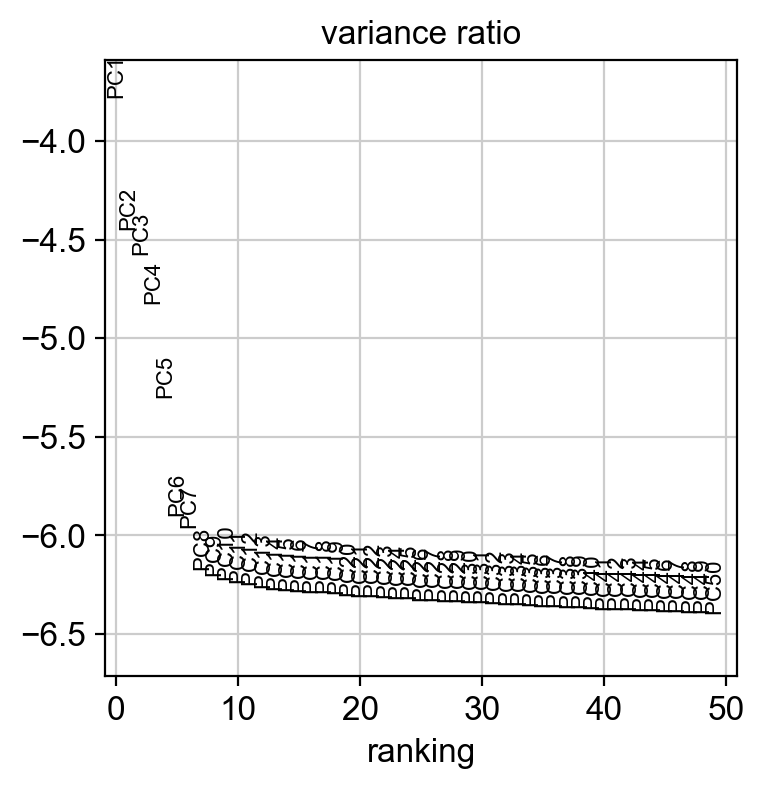

In [9]:
# PCA
sc.tl.pca(adata, n_comps=50, svd_solver="arpack")

# Elbow plot to guide PC selection
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [8]:
# Neighbor graph + UMAP + Leiden clustering
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=40)
sc.tl.umap(adata, min_dist=0.3)
sc.tl.leiden(adata, resolution=0.5)

n_clusters = adata.obs["leiden"].nunique()
print(f"Found {n_clusters} Leiden clusters")

/Users/patrickgrady/Documents/GitHub_Repositories/scRN_AI/.venv/lib/python3.11/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 2000 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


Found 5 Leiden clusters


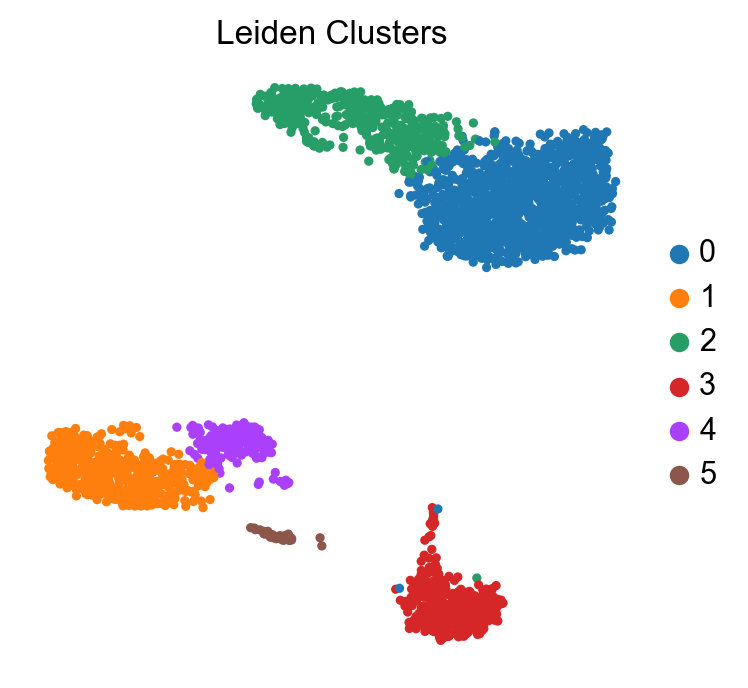

In [11]:
# UMAP colored by cluster
sc.pl.umap(adata, color="leiden", title="Leiden Clusters", frameon=False)

## 6. Marker Gene Detection

Use scRN_AI's `find_cluster_markers()` to identify differentially expressed genes per cluster,
then `filter_marker_genes()` to remove non-informative genes (ribosomal, mitochondrial, HSP).

This is the same logic that powers the AItyping workflow's marker detection step.

In [9]:
# Find cluster markers using scRN_AI
cluster_markers = find_cluster_markers(
    adata,
    cluster_key="leiden",
    n_genes=10,
    method="wilcoxon",
    min_fold_change=1.5,
    max_pval=0.05,
    only_positive=True,
)

print(f"Markers found for {len(cluster_markers)} clusters\n")
for cluster_id, markers in sorted(cluster_markers.items(), key=lambda x: int(x[0])):
    # Filter out ribosomal / mito / HSP genes
    filtered = filter_marker_genes(markers)
    print(f"  Cluster {cluster_id}: {', '.join(filtered[:5])}")

Markers found for 5 clusters

  Cluster 0: LDHB, CD3D, TPT1
  Cluster 1: FTL, FTH1, CST3, TYROBP, LYZ
  Cluster 2: NKG7, CST7, GZMA, CTSW, B2M
  Cluster 3: CD74, CD79A, HLA-DRA, CD79B, HLA-DPB1
  Cluster 4: HLA-DPB1, HLA-DPA1, FCER1A, HLA-DRA, HLA-DRB1


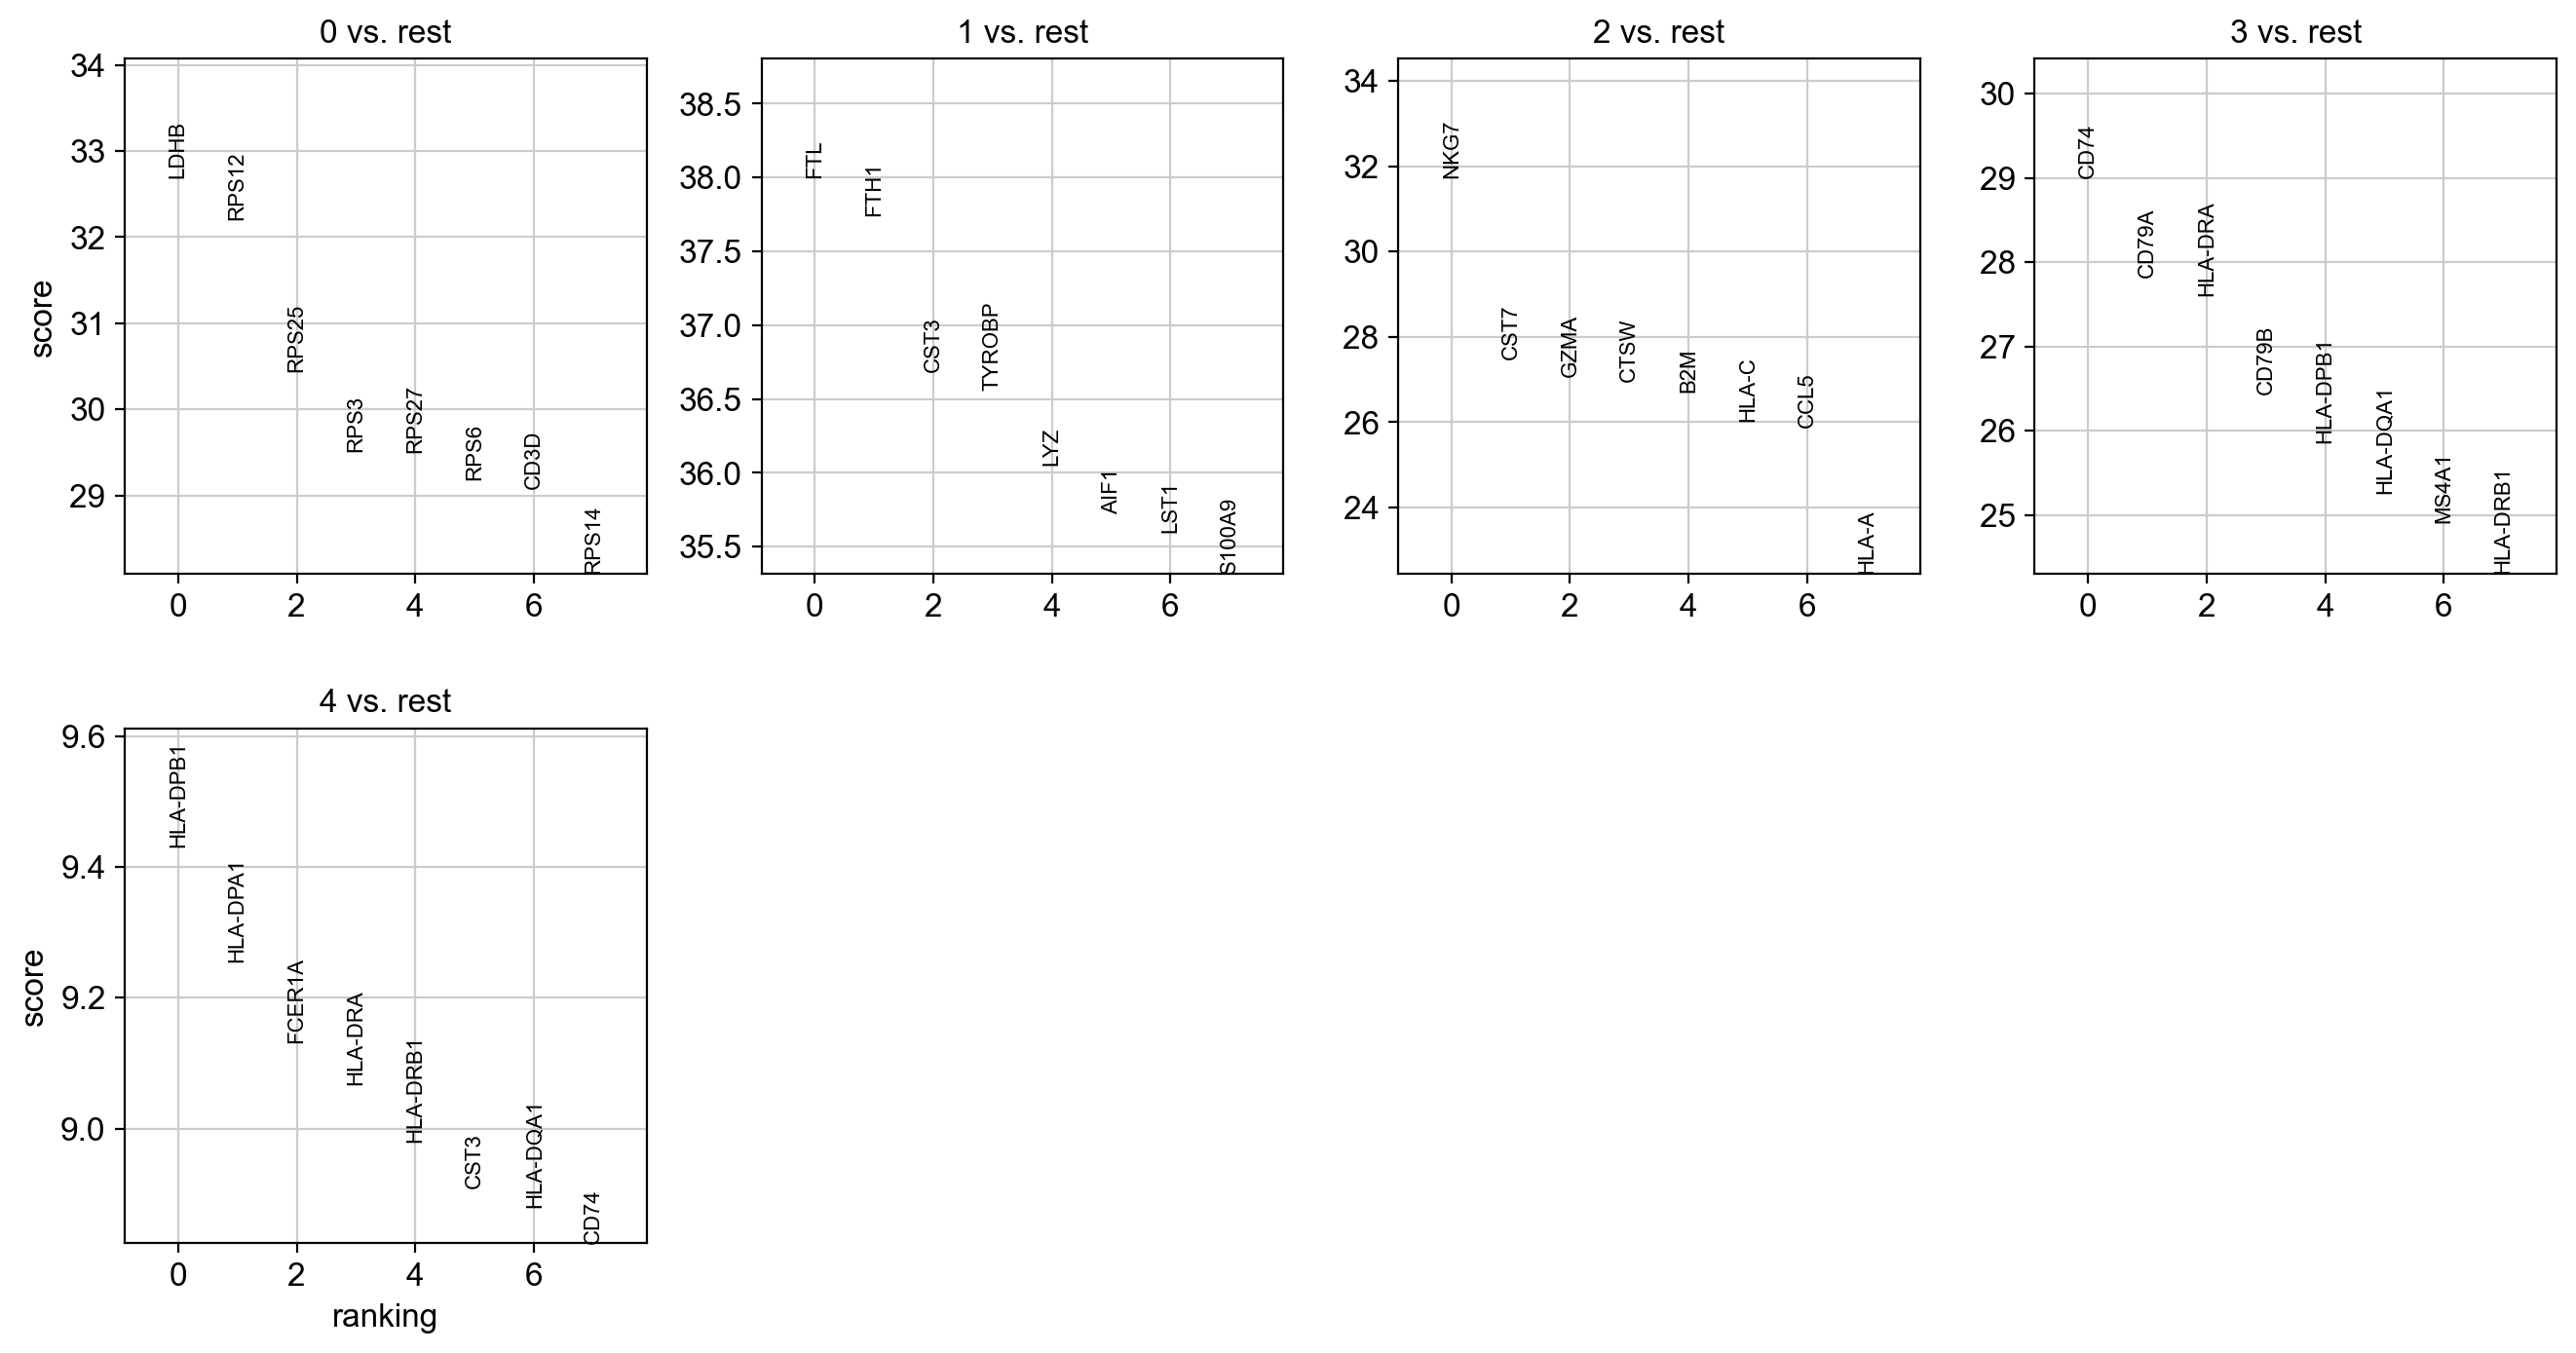

In [10]:
# Scanpy's built-in rank_genes_groups visualization
sc.pl.rank_genes_groups(adata, n_genes=8, sharey=False)

## 7. Cell Type Annotation

Based on marker genes, we can manually annotate clusters. In a production workflow,
you'd use `scrn_ai aitype` to have GPT-4 annotate clusters automatically based on
the detected markers.

For this demo, we assign canonical PBMC types based on the well-known marker patterns.

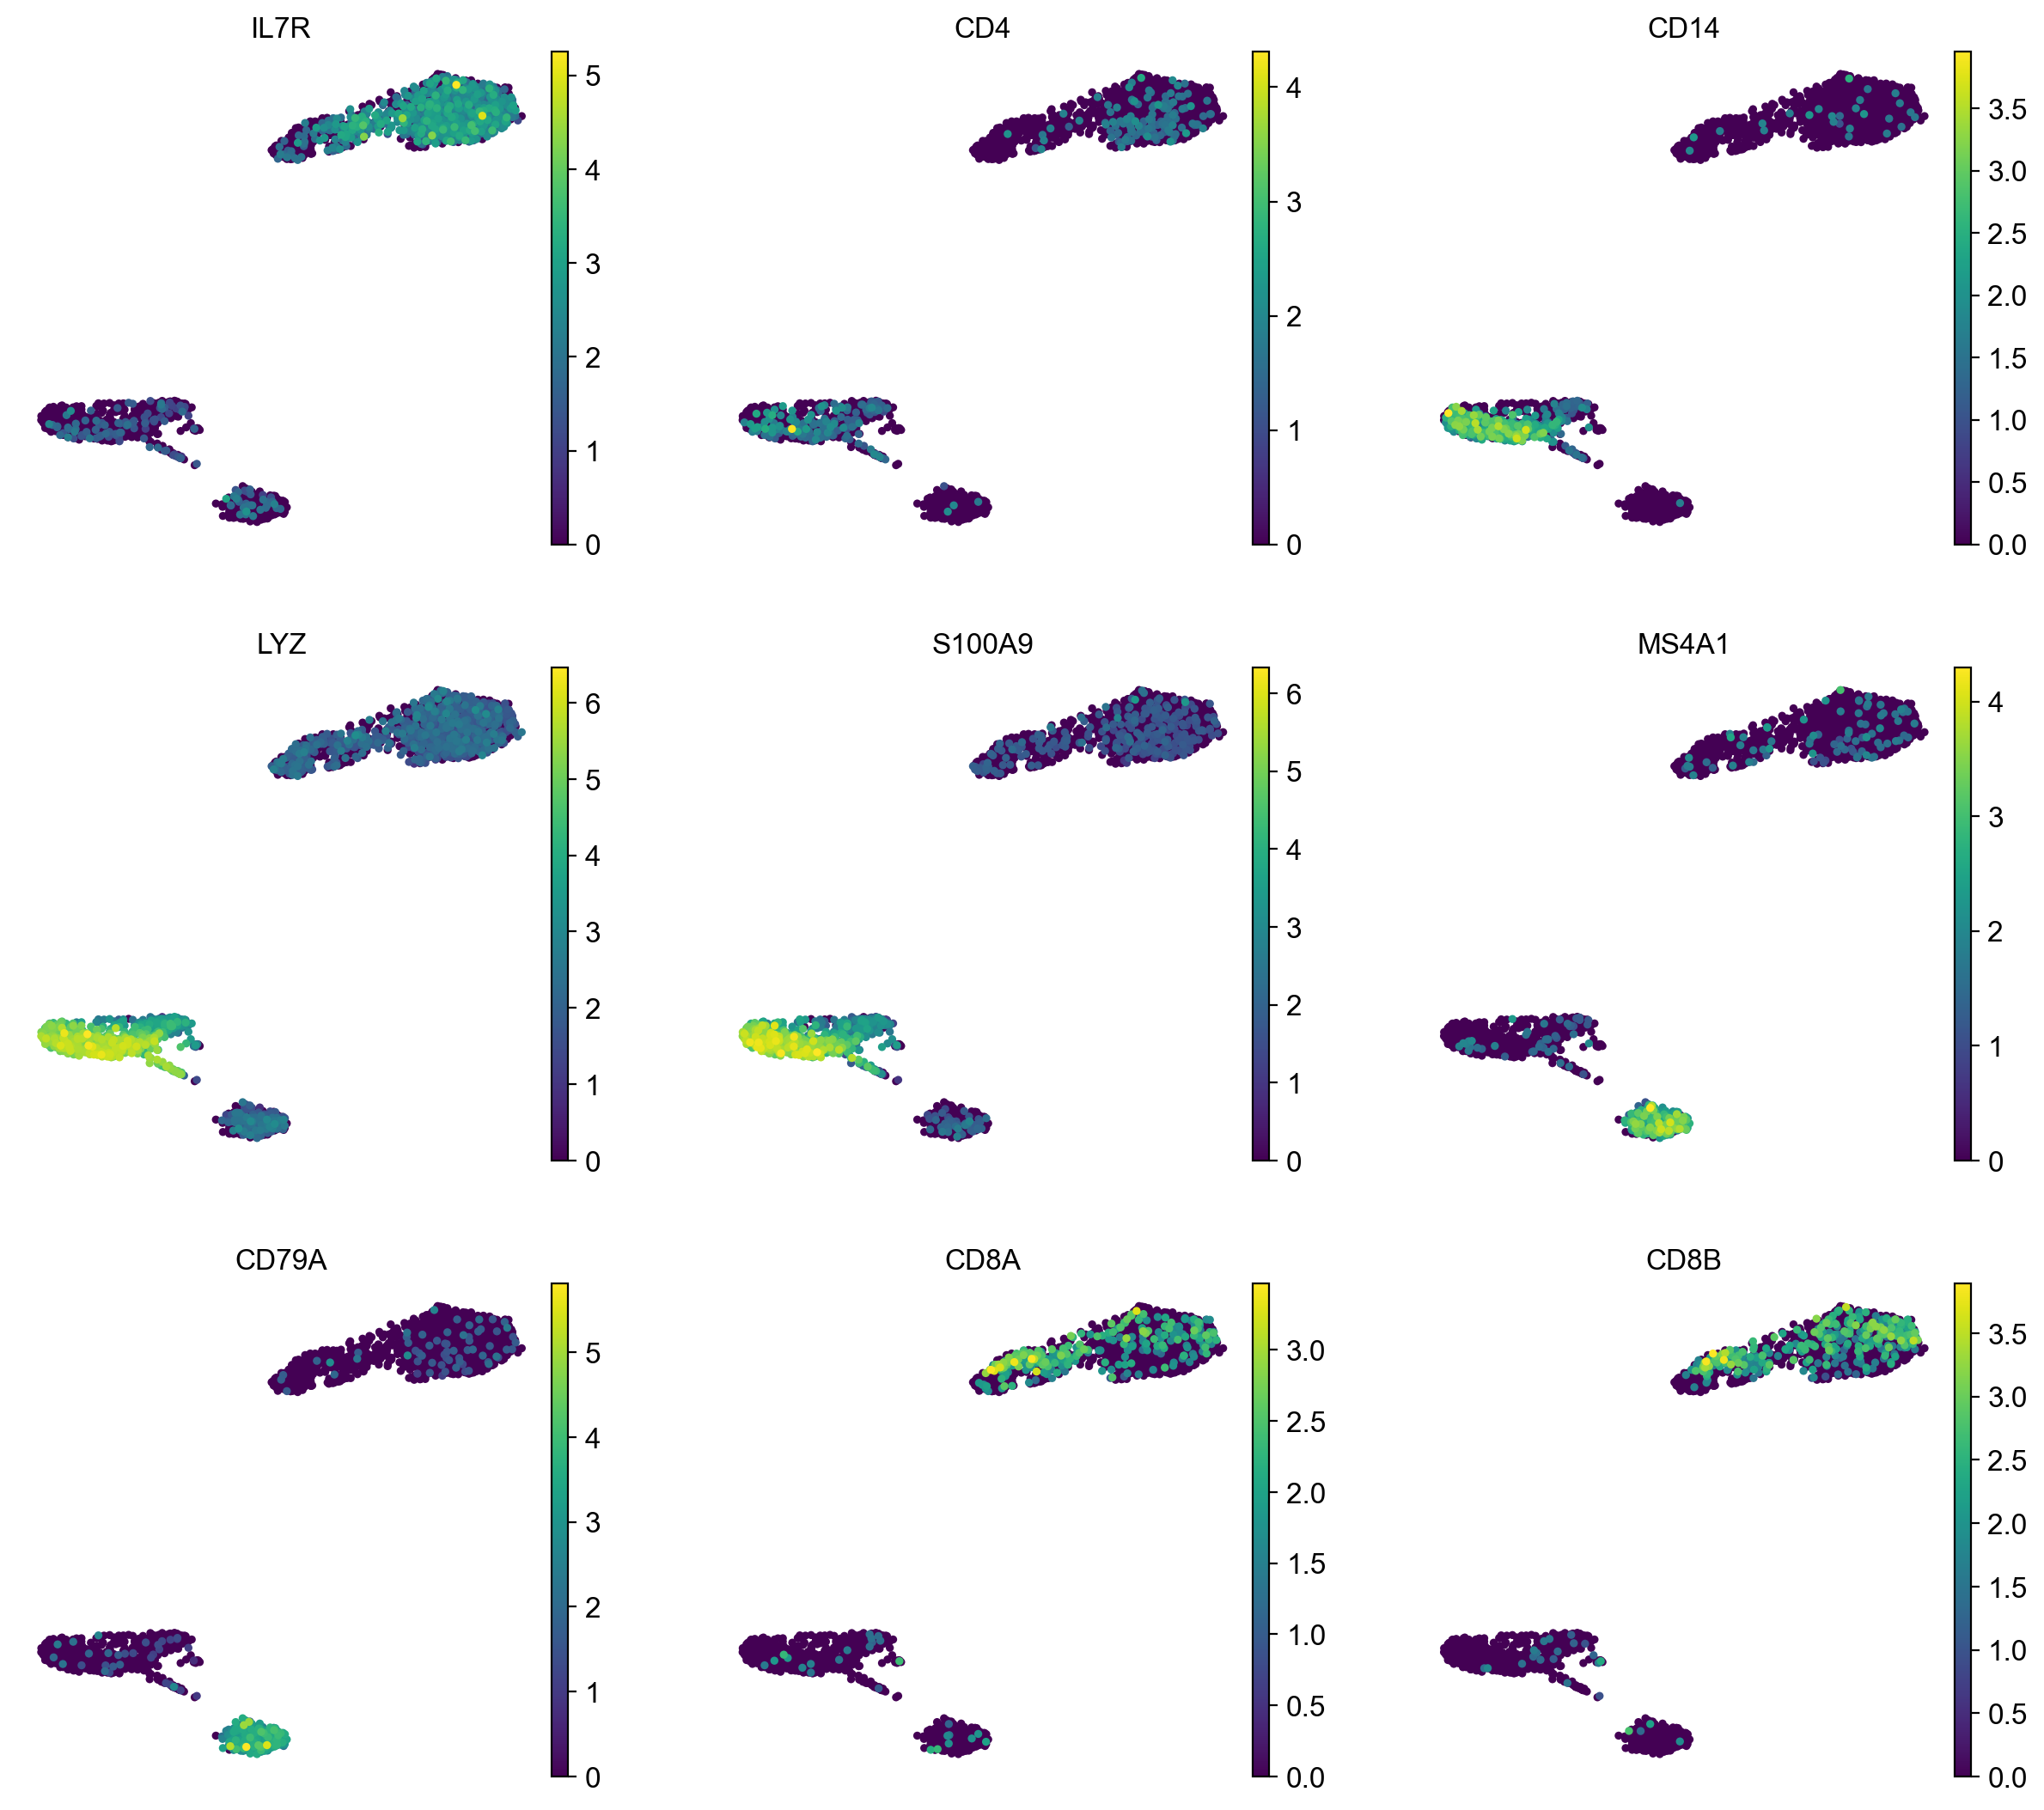

In [11]:
# Manual annotation based on canonical PBMC markers
# These assignments depend on the exact clustering — adjust if needed
canonical_markers = {
    "CD4+ T cells": ["IL7R", "CD4"],
    "CD14+ Monocytes": ["CD14", "LYZ", "S100A9"],
    "B cells": ["MS4A1", "CD79A"],
    "CD8+ T cells": ["CD8A", "CD8B"],
    "NK cells": ["GNLY", "NKG7"],
    "FCGR3A+ Monocytes": ["FCGR3A", "MS4A7"],
    "Dendritic cells": ["FCER1A", "CST3"],
    "Platelets": ["PPBP"],
}

# Show key markers on UMAP
marker_genes_flat = [g for genes in canonical_markers.values() for g in genes if g in adata.raw.var_names]
sc.pl.umap(adata, color=marker_genes_flat[:9], ncols=3, frameon=False, use_raw=True)

In [12]:
# Assign cell types based on top markers per cluster
# This is a simplified version — AItyping does this with GPT-4
new_cluster_names = {}
for cluster_id, markers in cluster_markers.items():
    filtered = filter_marker_genes(markers)
    # Simple heuristic: check which canonical type best matches
    best_type = "Unknown"
    best_score = 0
    for cell_type, canonical in canonical_markers.items():
        score = sum(1 for g in canonical if g in filtered)
        if score > best_score:
            best_score = score
            best_type = cell_type
    new_cluster_names[cluster_id] = best_type

# Apply annotations
adata.obs["cell_type"] = adata.obs["leiden"].map(new_cluster_names).fillna("Unknown")

print("Cluster → Cell Type mapping:")
for cid, ctype in sorted(new_cluster_names.items(), key=lambda x: int(x[0])):
    n = (adata.obs["leiden"] == cid).sum()
    print(f"  Cluster {cid}: {ctype} ({n} cells)")

Cluster → Cell Type mapping:
  Cluster 0: Unknown (1196 cells)
  Cluster 1: CD14+ Monocytes (651 cells)
  Cluster 2: NK cells (412 cells)
  Cluster 3: B cells (343 cells)
  Cluster 4: Dendritic cells (36 cells)


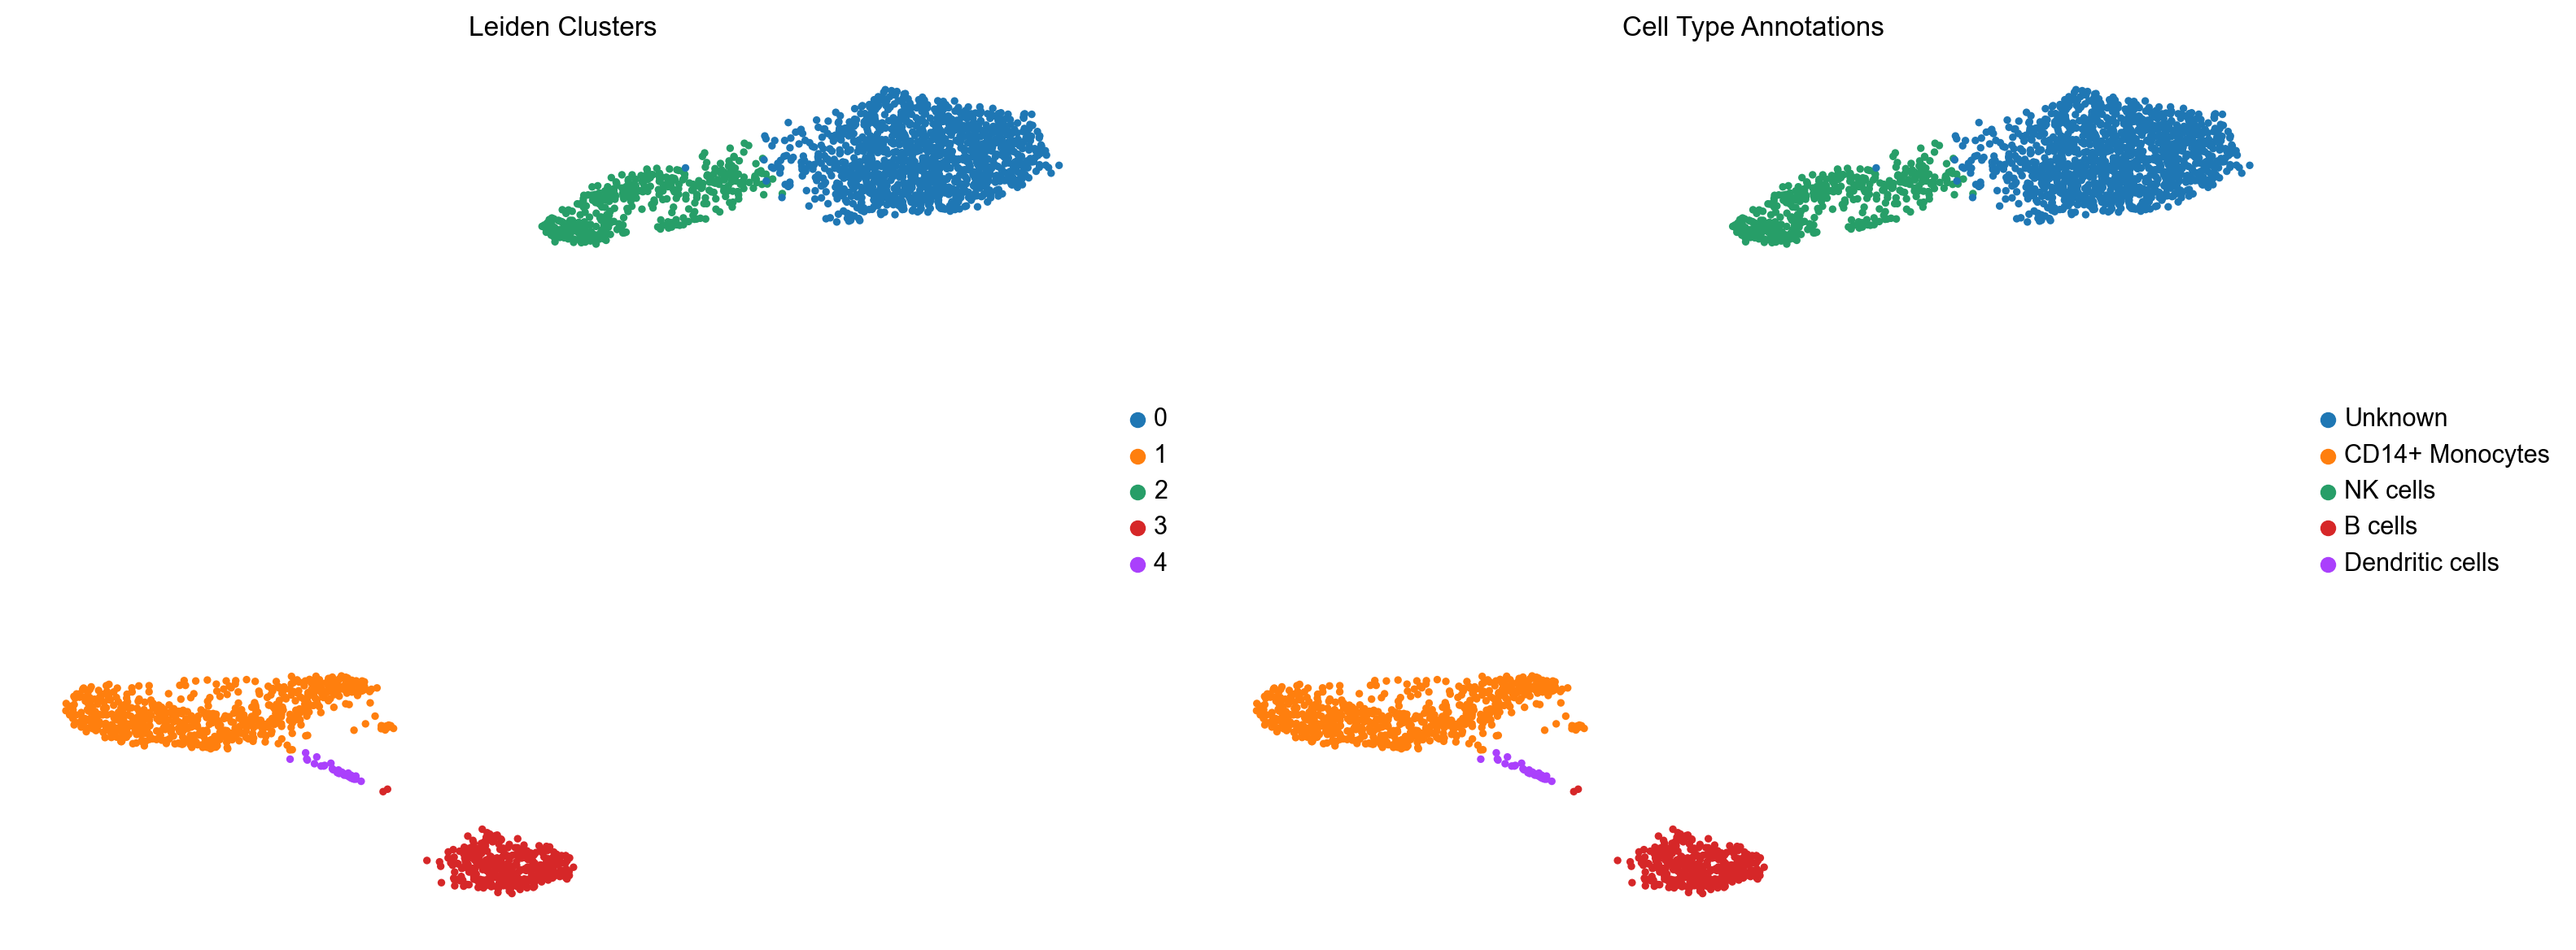

In [13]:
# UMAP with cell type labels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.umap(adata, color="leiden", ax=axes[0], show=False, title="Leiden Clusters", frameon=False)
sc.pl.umap(adata, color="cell_type", ax=axes[1], show=False, title="Cell Type Annotations", frameon=False)
plt.tight_layout()
plt.show()

## 8. Expression Visualization

Use scRN_AI's plotting utilities for publication-ready expression plots.

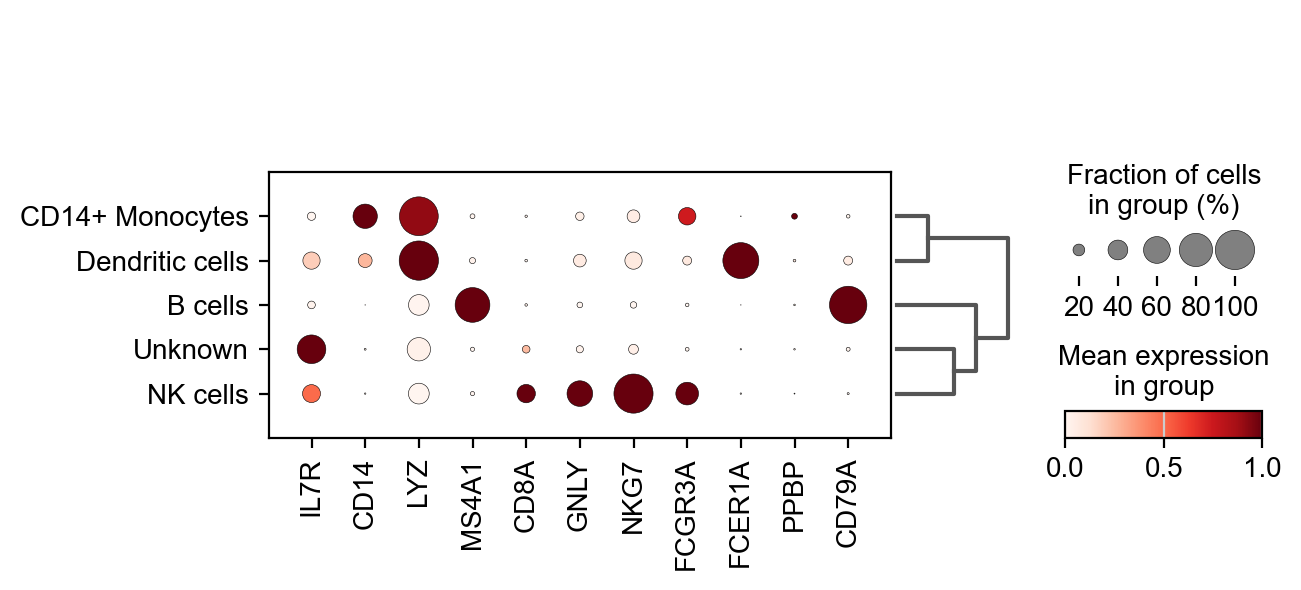

In [15]:
# Dot plot of canonical markers across cell types
display_genes = [g for g in ["IL7R", "CD14", "LYZ", "MS4A1", "CD8A", "GNLY", "NKG7", 
                              "FCGR3A", "FCER1A", "PPBP", "CD79A"]
                 if g in adata.raw.var_names]

# Pre-compute dendrogram so dotplot / stacked_violin don't warn
sc.tl.dendrogram(adata, groupby="cell_type")

sc.pl.dotplot(adata, var_names=display_genes, groupby="cell_type", use_raw=True,
              dendrogram=True, standard_scale="var")

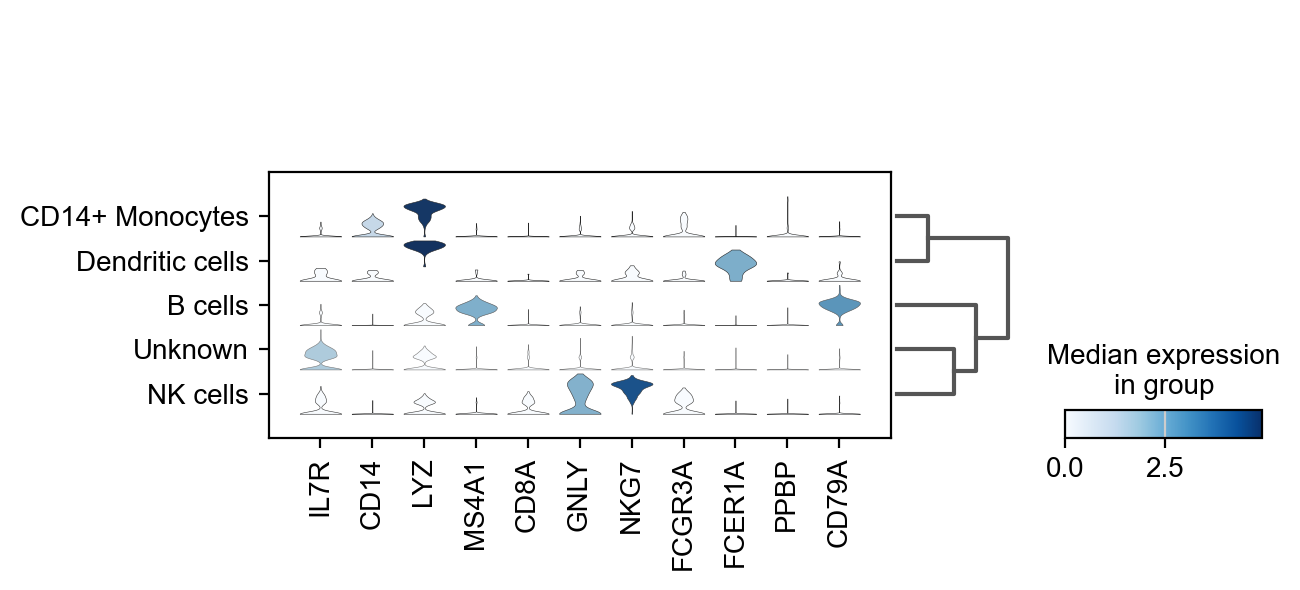

In [16]:
# Stacked violin of the same markers
sc.pl.stacked_violin(adata, var_names=display_genes, groupby="cell_type", use_raw=True,
                     dendrogram=True, swap_axes=False)

## 9. Pseudotime Analysis (DPT)

scRN_AI supports multiple pseudotime methods via the `pseudotime` command:
- **DPT** — Diffusion Pseudotime (small-scale, <50k cells)
- **Diffusion Maps** — first diffusion component as pseudotime
- **BLTSA** — R-based trajectory inference
- **VIA/STAVIA** — large-scale trajectory analysis (>50k cells)

Here we run DPT on the PBMC data, which mirrors `scrn_ai pseudotime --method dpt`.

In [18]:
# Diffusion map + DPT — same logic as workflows.pseudotime._run_small_scale()
sc.tl.diffmap(adata)

# Set root to a monocyte cell (they're often the "starting" population in PBMC)
monocyte_mask = adata.obs["cell_type"].str.contains("Monocyte", na=False)
if monocyte_mask.any():
    adata.uns["iroot"] = np.where(monocyte_mask)[0][0]
else:
    adata.uns["iroot"] = 0

sc.tl.dpt(adata)
adata.obs["pseudotime"] = adata.obs["dpt_pseudotime"]

print(f"Pseudotime range: {adata.obs['pseudotime'].min():.3f} → {adata.obs['pseudotime'].max():.3f}")

Pseudotime range: 0.000 → 1.000


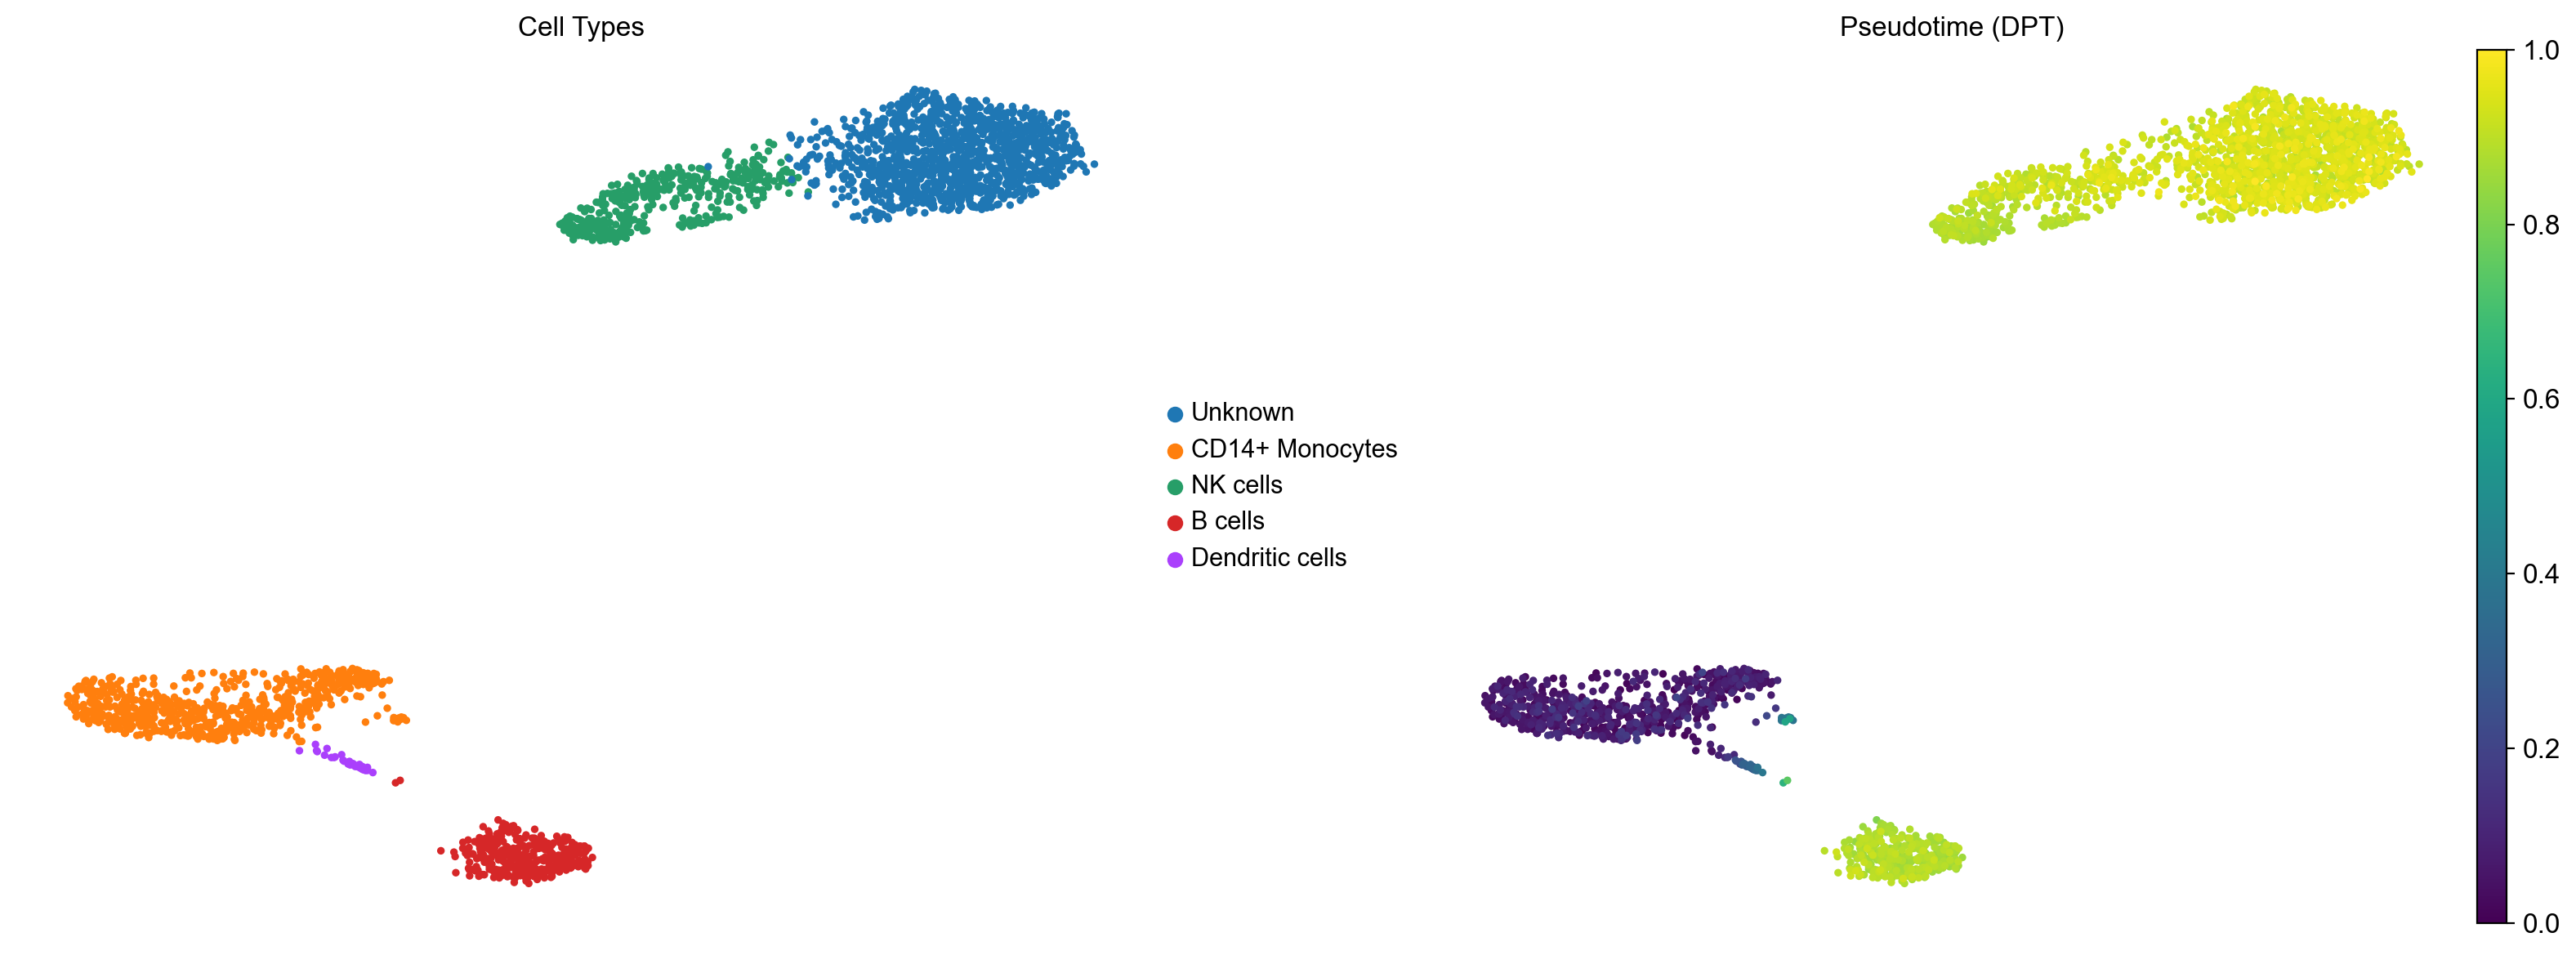

In [19]:
# Visualize pseudotime on UMAP — using scRN_AI's plot utility
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color="cell_type", ax=axes[0], show=False, title="Cell Types", frameon=False)
sc.pl.umap(adata, color="pseudotime", ax=axes[1], show=False, title="Pseudotime (DPT)",
           frameon=False, cmap="viridis")

plt.tight_layout()
plt.show()

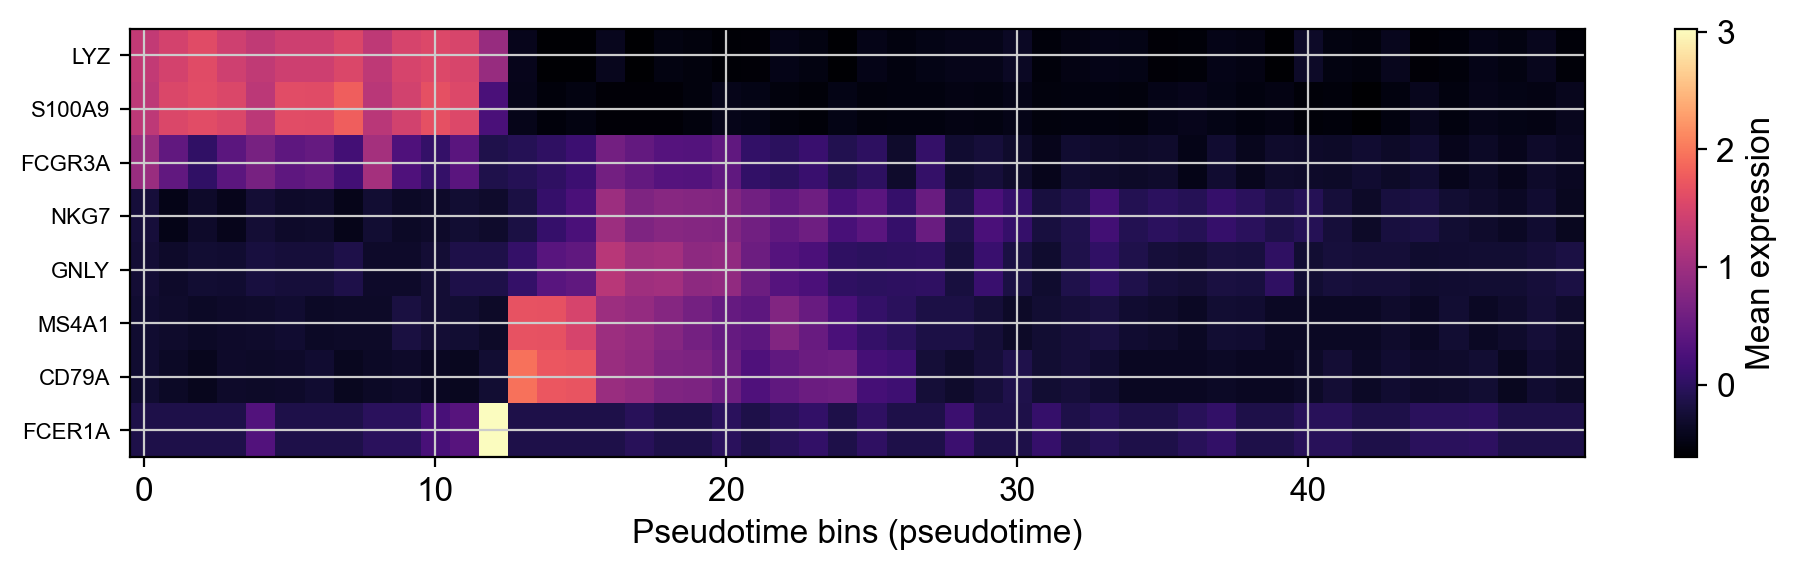

In [20]:
# Pseudotime heatmap of key genes — using scRN_AI's plot utility
trajectory_genes = [g for g in ["CD14", "LYZ", "S100A9", "FCGR3A", "MS4A7",
                                 "CD3D", "IL7R", "CD8A", "NKG7", "GNLY",
                                 "MS4A1", "CD79A", "FCER1A"]
                    if g in adata.var_names]

if trajectory_genes:
    pseudotime_heatmap(adata, genes=trajectory_genes, time_key="pseudotime", n_bins=50)
    plt.show()
else:
    print("Trajectory genes not in current variable set (subset to HVGs)")

## 10. Pipeline Summary & Statistics

In [21]:
# Summary statistics
print("=" * 60)
print("scRN_AI Pipeline Summary — PBMC 3k")
print("=" * 60)
print(f"Final dataset: {adata.n_obs} cells × {adata.n_vars} genes")
print(f"Leiden clusters: {adata.obs['leiden'].nunique()}")
print(f"Annotated cell types: {adata.obs['cell_type'].nunique()}")
print(f"\nCell type distribution:")
print(adata.obs["cell_type"].value_counts().to_string())
print(f"\nPseudotime computed: {'pseudotime' in adata.obs.columns}")
print(f"Diffusion map computed: {'X_diffmap' in adata.obsm}")
print(f"\nKey objects in adata:")
print(f"  .obs columns: {list(adata.obs.columns)}")
print(f"  .obsm keys: {list(adata.obsm.keys())}")
print(f"  .layers: {list(adata.layers.keys())}")

scRN_AI Pipeline Summary — PBMC 3k
Final dataset: 2638 cells × 2000 genes
Leiden clusters: 5
Annotated cell types: 5

Cell type distribution:
cell_type
Unknown            1196
CD14+ Monocytes     651
NK cells            412
B cells             343
Dendritic cells      36

Pseudotime computed: True
Diffusion map computed: True

Key objects in adata:
  .obs columns: ['n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'leiden', 'cell_type', 'dpt_pseudotime', 'pseudotime']
  .obsm keys: ['X_pca', 'X_umap', 'X_diffmap']
  .layers: ['counts']


In [22]:
# Save key figures for README
import os
fig_dir = os.path.join(os.path.dirname(os.getcwd()), "docs", "figures")
os.makedirs(fig_dir, exist_ok=True)

# 1. Canonical marker UMAPs (3×3 grid)
fig = sc.pl.umap(adata, color=marker_genes_flat[:9], ncols=3, frameon=False,
                 use_raw=True, show=False, return_fig=True)
fig.savefig(os.path.join(fig_dir, "marker_umaps.png"), dpi=150, bbox_inches="tight",
            facecolor="white")
plt.close(fig)

# 2. Dot plot of expression across cell types
dp = sc.pl.dotplot(adata, var_names=display_genes, groupby="cell_type", use_raw=True,
                   dendrogram=True, standard_scale="var", show=False, return_fig=True)
dp.savefig(os.path.join(fig_dir, "dotplot_expression.png"), dpi=150, bbox_inches="tight")
plt.close("all")

# 3. Pseudotime UMAP (cell type + DPT side by side)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.umap(adata, color="cell_type", ax=axes[0], show=False, title="Cell Types", frameon=False)
sc.pl.umap(adata, color="pseudotime", ax=axes[1], show=False, title="Pseudotime (DPT)",
           frameon=False, cmap="viridis")
plt.tight_layout()
fig.savefig(os.path.join(fig_dir, "pseudotime_umap.png"), dpi=150, bbox_inches="tight",
            facecolor="white")
plt.close(fig)

print(f"Figures saved to {fig_dir}/")
for f in sorted(os.listdir(fig_dir)):
    print(f"  {f}")

Figures saved to /Users/patrickgrady/Documents/GitHub_Repositories/scRN_AI/docs/figures/
  dotplot_expression.png
  marker_umaps.png
  pseudotime_umap.png


## Summary

This notebook demonstrated the **complete scRN_AI pipeline** on real PBMC data:

- **QC** — `workflows.preprocess` logic with `utils.plot.qc_violin()` and `qc_scatter()`
- **Normalization** — `workflows.normalization` (log1p method)
- **HVG selection** — `utils.marker_detection.identify_variable_genes()`
- **Clustering** — PCA → neighbors → UMAP → Leiden
- **Marker detection** — `utils.marker_detection.find_cluster_markers()` + `filter_marker_genes()`
- **Cell type annotation** — manual heuristic (or use `scrn_ai aitype` for GPT-4 powered annotation)
- **Visualization** — `utils.plot.dotplot()`, `stacked_violin()`, UMAP overlays
- **Pseudotime** — `workflows.pseudotime` (DPT) + `utils.plot.pseudotime_heatmap()`

### CLI equivalents

The same analysis can be run from the command line:

```bash
# Step 1: Preprocess
scrn_ai preprocess -i raw.h5ad -o qc.h5ad --min-genes 200 --max-mito-pct 5

# Step 2: Normalize
scrn_ai normalize -i qc.h5ad -o norm.h5ad --method log1p

# Step 3: Visualize
scrn_ai umap -i norm.h5ad -o umap.png --color-by leiden

# Step 4: Pseudotime
scrn_ai pseudotime -i norm.h5ad -o trajectory.h5ad --method dpt

# Step 5: AI-powered annotation (requires OpenAI API key)
scrn_ai aitype -i norm.h5ad -o annotations/ --model gpt-4
```

---

*scRN_AI v1.0.0 — Any usage is subject to this software's license.*